# Buổi 8: Phân tích dự đoán đa biến

### PHÂN TÍCH MỐI TƯƠNG QUAN: CHI PHÍ QUẢNG CÁO & DOANH THU
1. Xây dựng mô hình hồi quy tuyến tính để dự báo doanh thu 
2. Đánh giá hiệu quả đầu tư (ROI) để tối ưu hóa ngân sách MKT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


df = pd.read_csv("./ads_data.csv")
print(df.head()) # 5 dòng đầu

   Advertising Cost (USD)  Sales Revenue (USD)
0                     784          5167.683485
1                     659          4736.040926
2                     729          4799.105662
3                     292          2307.039663
4                     935          5917.849078


In [13]:
# Khám phá dữ liệu: Kiểm tra dữ liệu null hay không ,... (dữ liệu đẹp rồi nên không cần làm sạch)


In [14]:
# Thông tin dữ liệu
print(df.info())

# Thống kê mô tả
display(df.describe())

# Tính ROI trung bình (Revenue/ Cost)
df['ROI'] = df['Sales Revenue (USD)'] / df['Advertising Cost (USD)']
print(f"\nROI trung bình hệ thống: {df['ROI'].mean():.2f}") # 7.06 Tỉ suất hoàn vốn. Chỉ số đo lường tỷ lệ 
# lợi nhuận dòng thu về so với chi phí đầu tư ban đầu. EXP: Bỏ ra 1 đồng, bạn thu về bao nhiêu đồng lời?
### Công thức ROI = Lợi nhuận/ chi phí * 100% => Lợi nhuận dòng = Doanh thu - chi phí.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Advertising Cost (USD)  35 non-null     int64  
 1   Sales Revenue (USD)     35 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes
None


,Advertising Cost (USD),Sales Revenue (USD)
count,35.000000,35.000000
mean,629.485714,4293.302903
std,263.089604,1626.940255
min,109.000000,841.300662
25%,436.500000,3079.228924
50%,700.000000,4736.040926
75%,838.500000,5605.599831
max,949.000000,6369.142270



ROI trung bình hệ thống: 7.06


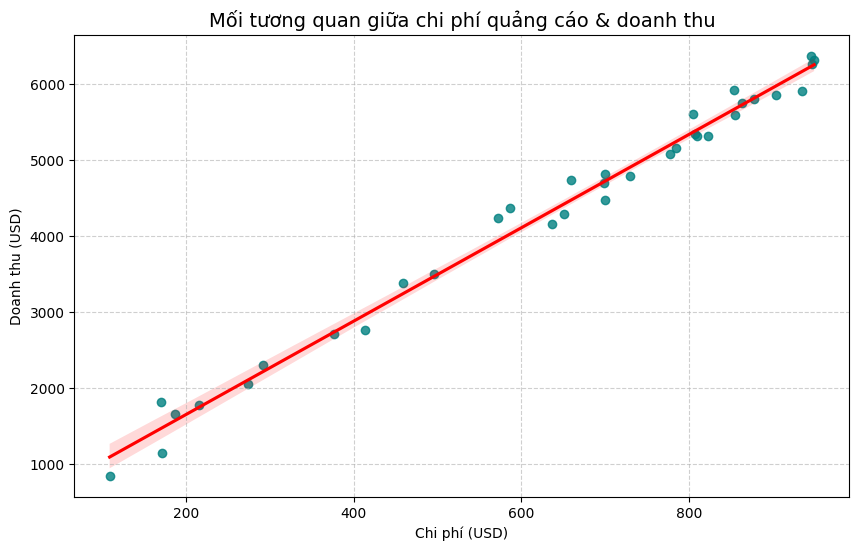

In [15]:
### Trực quan hóa dữ liệu (Vẽ biểu đồ: Scatter Plot - biểu đồ phân tán) 
##=>  để xem liệu có mối quan hệ tuyến tính giữa chi phí và doanh thu hay.
plt.figure(figsize=(10,6))
sns.regplot(data=df, x="Advertising Cost (USD)", y="Sales Revenue (USD)", color="teal", line_kws={"color":"red"})
plt.title("Mối tương quan giữa chi phí quảng cáo & doanh thu", fontsize=14)
plt.xlabel('Chi phí (USD)')
plt.ylabel("Doanh thu (USD)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
## Xây dựng mô hình hồi quy: Huấn luyện mô hình Linear Regression
## Sử dụng Scikit-learn để tìm phương trình $Y = aX + b$
# Chuẩn bị dữ liệu
X = df[["Advertising Cost (USD)"]] # Feature
y = df['Sales Revenue (USD)'] # Target

# Khởi tạo & Huấn luyện
model = LinearRegression()
model.fit(X, y)


# Kết quả
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X,y)

print(f"Hệ số góc (Slope): {slope:.4f}")
print(f'Điểm cắt (Intercept): {intercept:.4f}')
print(f"Độ tin cậy (R-squared): {r2:.4f}")


Hệ số góc (Slope): 6.1473
Điểm cắt (Intercept): 423.6453
Độ tin cậy (R-squared): 0.9882


In [ ]:
### Kết luận chiến lược
## Dựa trên mô hình, ta có phương trình dự báo doanh thu 
## Revenue = 6.1473*Ad_Cost + 423.6453

## R-SQUARED = 0.988: Mô hình cực kỳ chính xác
## Chiến lược: Mỗi 1 USD quảng cáo => mang lại ~ 6.15$ doanh thu. Đây là một biên lợi nhuận tốt.